In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [2]:
hidden = np.load('/Users/taniyashuba/PycharmProjects/NeuroSymbolicDynamics/train models/hidden_rnn.npy')  # убедитесь, что файл в той же папке
print("Loaded hidden states:", hidden.shape)  # (N, d)

Loaded hidden states: (500, 64)


In [3]:
# 2. Time-delay embedding
tau, m = 1, 3
embedded = []
N, d = hidden.shape
for i in range(N - (m-1)*tau):
    vec = hidden[i].copy()
    for j in range(1, m):
        vec = np.concatenate([vec, hidden[i + j*tau]], axis=0)
    embedded.append(vec)
X_td = np.array(embedded)
print("Embedded shape:", X_td.shape)  # (N_td, m*d)

Embedded shape: (498, 192)


In [4]:
# 3. Символизация k-means
k = 4
km = KMeans(n_clusters=k, random_state=0).fit(X_td)
symbols = km.labels_

In [5]:
# 4. Матрица переходов
P = np.zeros((k, k))
counts = np.zeros(k)
for t in range(len(symbols)-1):
    P[symbols[t], symbols[t+1]] += 1
    counts[symbols[t]] += 1
P_norm = (P.T / counts).T

In [6]:
# 5. Lempel–Ziv сложность
def lz_complexity(s):
    n, i, c, l = len(s), 0, 1, 1
    while True:
        if i + l > n-1:
            c += 1; break
        if s[i:i+l] in s[:i+l-1]:
            l += 1
        else:
            c += 1; i += l; l = 1
        if i + l > n-1:
            c += 1; break
    return c

symbol_str = ''.join(map(str, symbols))
lz_val = lz_complexity(symbol_str)
print("LZ complexity:", lz_val)

LZ complexity: 15


In [7]:
# 6. Корреляционная размерность D2
dists = np.linalg.norm(X_td[:,None] - X_td[None,:], axis=2)
rs = np.logspace(-2, 0, 10)
C_vals = [(dists < r).sum()/(len(X_td)**2) for r in rs]
log_r = np.log(rs[:6])
log_C = np.log(C_vals[:6])
D2 = LinearRegression().fit(log_r.reshape(-1,1), log_C).coef_[0]
print("Correlation dimension D2:", D2)

Correlation dimension D2: 0.14721533458466357


In [8]:
# 7. Mapper-граф: определяем узлы и рёбра
# 7a. фильтр по первой PCA-координате
pca1 = PCA(1).fit(X_td)
f_vals = pca1.transform(X_td).flatten()
n_bins = 5
min_f, max_f = f_vals.min(), f_vals.max()
span = (max_f - min_f) / (n_bins - (n_bins-1)*0.5)
bins = [(min_f + i*span*0.5, min_f + i*span*0.5 + span) for i in range(n_bins)]

In [9]:
# 7b. узлы
mapper_nodes = []
for b_idx, (low, high) in enumerate(bins):
    idxs = np.where((f_vals>=low)&(f_vals<=high))[0]
    if len(idxs)==0: continue
    sub = X_td[idxs]
    km2 = KMeans(n_clusters=2, random_state=0).fit(sub)
    for lbl in np.unique(km2.labels_):
        pts = set(idxs[km2.labels_==lbl])
        mapper_nodes.append({'name':f"{b_idx}-{lbl}", 'bin':b_idx, 'pts':pts})

In [10]:
# 7c. рёбра
mapper_edges = []
for a in mapper_nodes:
    for b in mapper_nodes:
        if b['bin']==a['bin']+1 and a['pts'] & b['pts']:
            mapper_edges.append((a['name'], b['name']))

# 8. Визуализация


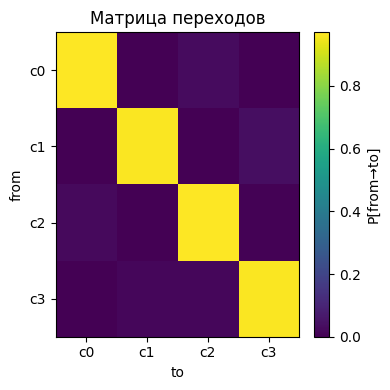

In [11]:
# --- 8.1 Heatmap переходов ---
plt.figure(figsize=(4,4))
plt.imshow(P_norm, cmap='viridis', aspect='auto')
plt.colorbar(label="P[from→to]")
plt.xticks(range(k), [f"c{j}" for j in range(k)])
plt.yticks(range(k), [f"c{i}" for i in range(k)])
plt.title("Матрица переходов")
plt.xlabel("to")
plt.ylabel("from")
plt.tight_layout()
plt.show()

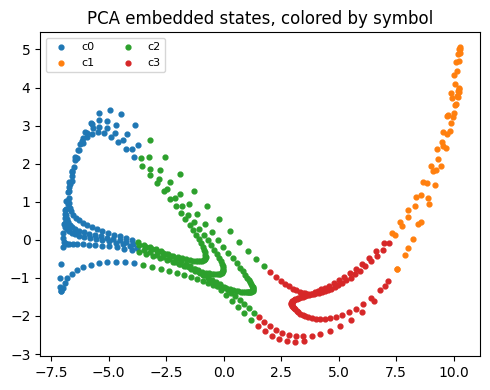

In [12]:
# --- 8.2 Scatter PCA(2) по символам ---
pca2 = PCA(2).fit(X_td)
coords2 = pca2.transform(X_td)
plt.figure(figsize=(5,4))
for sym in range(k):
    plt.scatter(coords2[symbols==sym,0],
                coords2[symbols==sym,1],
                label=f"c{sym}", s=12)
plt.legend(ncol=2, fontsize=8)
plt.title("PCA embedded states, colored by symbol")
plt.tight_layout()
plt.show()

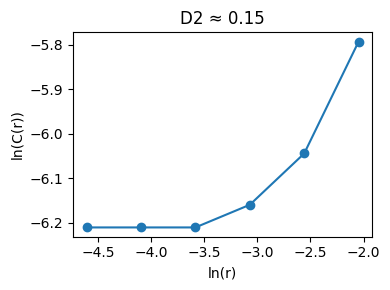

In [13]:
# --- 8.3 Correlation dimension plot ---
plt.figure(figsize=(4,3))
plt.plot(log_r, log_C, 'o-')
plt.title(f"D2 ≈ {D2:.2f}")
plt.xlabel("ln(r)")
plt.ylabel("ln(C(r))")
plt.tight_layout()
plt.show()

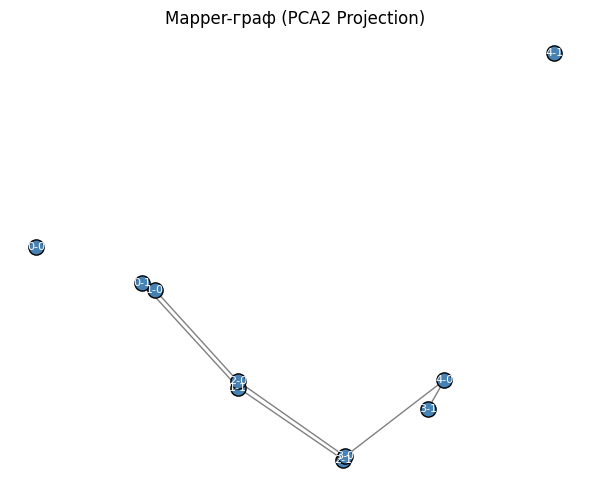

In [14]:
# --- 8.4 Mapper-граф в PCA2 ---
# получаем координаты узлов в coords2
for node in mapper_nodes:
    pts = list(node['pts'])
    node['xy'] = coords2[pts].mean(axis=0)

plt.figure(figsize=(6,5))
# рёбра
lines = [[next(n for n in mapper_nodes if n['name']==src)['xy'],
          next(n for n in mapper_nodes if n['name']==tgt)['xy']]
         for src, tgt in mapper_edges]
lc = LineCollection(lines, colors='gray', linewidths=1)
ax = plt.gca(); ax.add_collection(lc)
# узлы
for n in mapper_nodes:
    x,y = n['xy']
    plt.scatter(x, y, s=120, color='steelblue', edgecolors='k', zorder=2)
    plt.text(x, y, n['name'], ha='center', va='center', color='white', fontsize=8)
plt.title("Mapper-граф (PCA2 Projection)")
plt.axis('off')
plt.tight_layout()
plt.show()

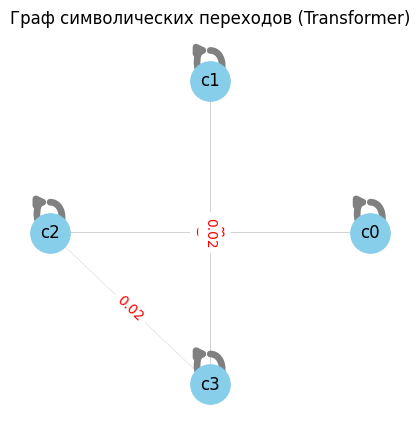

In [15]:
import networkx as nx

# 9.5 Символьный граф переходов
G = nx.DiGraph()
# Добавляем узлы-символы
for i in range(k):
    G.add_node(f"c{i}")
# Добавляем рёбра с весами из P_norm
for i in range(k):
    for j in range(k):
        w = P_norm[i, j]
        if w > 0:
            G.add_edge(f"c{i}", f"c{j}", weight=w)

plt.figure(figsize=(5,5))
pos = nx.circular_layout(G)
edge_widths = [G[u][v]['weight']*5 for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=12,
                       width=edge_widths, edge_color='gray')
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title("Граф символических переходов (Transformer_old)")
plt.axis('off')
plt.show()